# PR-7: Layer-0 Baseline + `last_ctx` Pooling

Two additions from PR-7:

| Addition | Key | Purpose |
|---|---|---|
| Layer -1 baseline | `key=-1` in extractor | Post-projection, pre-attention activation -- asks *how much does the patch embedding alone do?* |
| `last_ctx` pooling | `pooling='last_ctx'` | Position-31 (last context patch) only -- removes the positional confound when comparing encoder vs decoder |

**Scientific questions answered here:**

1. Is R^2 at layer -1 high (> 0.5)? If so, deeper layers largely read off embedding-level information.
2. Does `last_ctx` differ from `mean_ctx`? The decoder concentrates context at the last position; the encoder spreads it bidirectionally.
3. Does the encoder/decoder gap change under `last_ctx`? A single fixed probe position removes the "encoder attends everywhere from position 0" confound.

## Running

**Option A** -- Load pre-computed JSONs (run `train_probes.py` first):
```bash
python -m experiments.mech_interp.block1_probing.train_probes \
    --moiraie-ckpt <path> --moiraic-ckpt <path>
```

**Option B** -- Run inline (uses real checkpoints if found, else tiny in-memory models).

In [1]:
import glob
import json
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
RESULTS_DIR  = os.path.join(NOTEBOOK_DIR, 'results')
FIGURES_DIR  = os.path.join(NOTEBOOK_DIR, 'figures', 'pr7')
os.makedirs(FIGURES_DIR, exist_ok=True)

# Real checkpoint paths (from CLAUDE.md)
CKPT = {
    'moiraie': '/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraie/gift_eval_pretrain_weighted/moiraie_training_7/HF_checkpoints/last',
    'moiraic': '/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraic/gift_eval_pretrain_weighted/moiraic_training_11/HF_checkpoints/last',
}

print(f'Results dir : {RESULTS_DIR}')
print(f'Figures dir : {FIGURES_DIR}')


Results dir : /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/results
Figures dir : /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr7


## Helper functions

In [2]:
POOLING_MODES  = ('mean_ctx', 'last_ctx')
POOLING_LABELS = {'mean_ctx': 'mean_ctx (all 32 patches)', 'last_ctx': 'last_ctx (position 31)'}
POOLING_LS     = {'mean_ctx': '-', 'last_ctx': '--'}


def load_results(path):
    """Load PR-7 JSON: {pooling_mode: {feature: {layer_int: score}}}.
    Returns None if the file is in the old (pre-PR-7) format.
    """
    with open(path) as f:
        raw = json.load(f)
    # New format: top-level keys are pooling modes
    if not set(raw.keys()) <= {'mean_ctx', 'last_ctx'}:
        return None
    return {
        pooling: {feat: {int(k): v for k, v in layers.items()}
                  for feat, layers in feat_dict.items()}
        for pooling, feat_dict in raw.items()
    }


def layer_x_positions(layer_keys):
    """Sorted keys -> (keys, x_positions, tick_labels). Key -1 labelled 'embed'."""
    keys   = sorted(layer_keys)
    x_pos  = list(range(len(keys)))
    labels = ['embed\n(-1)' if k == -1 else str(k) for k in keys]
    return keys, x_pos, labels


def get_scores(results, model, pooling, feature):
    """Return (sorted_layer_keys, scores_array) for one cell."""
    layer_scores = results[model][pooling].get(feature, {})
    keys   = sorted(layer_scores)
    scores = np.array([layer_scores[k] for k in keys])
    return keys, scores


print('Helpers defined.')


Helpers defined.


## Load or generate probe results

In [3]:
import torch
from experiments.mech_interp.lib.synthetic import generate_dataset
from experiments.mech_interp.block1_probing.train_probes import (
    run_probes_for_model, PATCH_SIZE, PRED_PATCHES,
)

# -- Try pre-computed JSONs ---------------------------------------------------
candidate_jsons = sorted(glob.glob(os.path.join(RESULTS_DIR, '*.json')))
candidate_jsons = [p for p in candidate_jsons
                   if 'metadata' not in p and 'per_patch' not in p]

results = {}
for p in candidate_jsons:
    name = os.path.splitext(os.path.basename(p))[0]
    data = load_results(p)  # returns None if old format
    if data is not None:
        results[name] = data
        print(f'Loaded {name} from {p}')
    else:
        print(f'Skipping {p}: old format (no pooling keys)')

# -- Run inline if nothing loaded --------------------------------------------
if not results:
    print('No PR-7 JSONs found. Running probes inline.')

    def _load_module(model_name, device):
        from uni2ts.model.moiraie.module import MoiraieModule
        from uni2ts.model.moiraic.module import MoiraicModule
        tiny = dict(d_model=64, d_ff=128, num_layers=2, patch_size=PATCH_SIZE,
                    max_seq_len=64, attn_dropout_p=0.0, dropout_p=0.0)
        ckpt = CKPT.get(model_name, '')
        if ckpt and os.path.isdir(ckpt):
            print(f'  Loading {model_name} from checkpoint...')
            cls = MoiraieModule if model_name == 'moiraie' else MoiraicModule
            return cls.from_pretrained(ckpt).eval().to(device)
        print(f'  No checkpoint for {model_name} -- tiny in-memory model.')
        if model_name == 'moiraie':
            return MoiraieModule(**tiny, num_predict_token=1).eval().to(device)
        return MoiraicModule(**tiny, num_predict_token=PRED_PATCHES).eval().to(device)

    device = 'cuda:6' if torch.cuda.is_available() else 'cpu'
    dataset = generate_dataset(n=100, seed=42)
    rng = np.random.default_rng(42)
    idx = rng.permutation(100)
    train_idx, val_idx = idx[:80], idx[80:]
    print(f'Device: {device}  |  dataset: {len(dataset["series"])} series')

    for model_name in ('moiraie', 'moiraic'):
        print(f'\n=== {model_name} ===')
        module = _load_module(model_name, device)
        results[model_name] = run_probes_for_model(
            module, dataset, train_idx, val_idx, batch_size=32, device=device
        )

# -- Summarise ----------------------------------------------------------------
model_names  = list(results.keys())
sample_model = next(iter(results.values()))
all_features = list(dict.fromkeys(f for pm in sample_model.values() for f in pm))
sample_scores = next(iter(next(iter(sample_model.values())).values()))
all_layer_keys = sorted(sample_scores.keys())

prop_cycle   = plt.rcParams['axes.prop_cycle'].by_key()['color']
model_colors = {n: prop_cycle[i % len(prop_cycle)] for i, n in enumerate(model_names)}

print(f'\nModels     : {model_names}')
print(f'Pooling    : {list(sample_model.keys())}')
print(f'Features   : {all_features}')
print(f'Layer keys : {all_layer_keys}  (-1 = embed baseline)')


Skipping /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/results/moiraic.json: old format (no pooling keys)
Skipping /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/results/moiraie.json: old format (no pooling keys)
No PR-7 JSONs found. Running probes inline.
Device: cuda:6  |  dataset: 100 series

=== moiraie ===
  Loading moiraie from checkpoint...
Loading weights from local directory
  Extracting train activations [mean_ctx] (80 examples)...
  Extracting val activations [mean_ctx] (20 examples)...
    [mean_ctx] slope: best layer score = 0.8758
    [mean_ctx] log_noise_var: best layer score = 0.4936
    [mean_ctx] phase_cos: best layer score = 0.5003
    [mean_ctx] phase_sin: best layer score = 0.2488
    [mean_ctx] period_idx: best layer score = 0.9000
  Extracting train activations [last_ctx] (80 examples)...
  Extracting val activations [last_ctx] (20 examples)...
    [last_ctx] slope: best layer score = 0.9153
    [last_ctx] log_noise_var: bes

## 1 · Layer-0 (embedding) baseline diagnostic

Bars compare the **patch-embedding score** (layer key = -1) against the **peak score** achieved by any transformer layer.

The percentage annotation is `embed_score / peak_score`. The red dotted line marks R^2 = 0.5 (rough threshold for 'embedding dominates').


Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr7/baseline_bar_mean_ctx.pdf


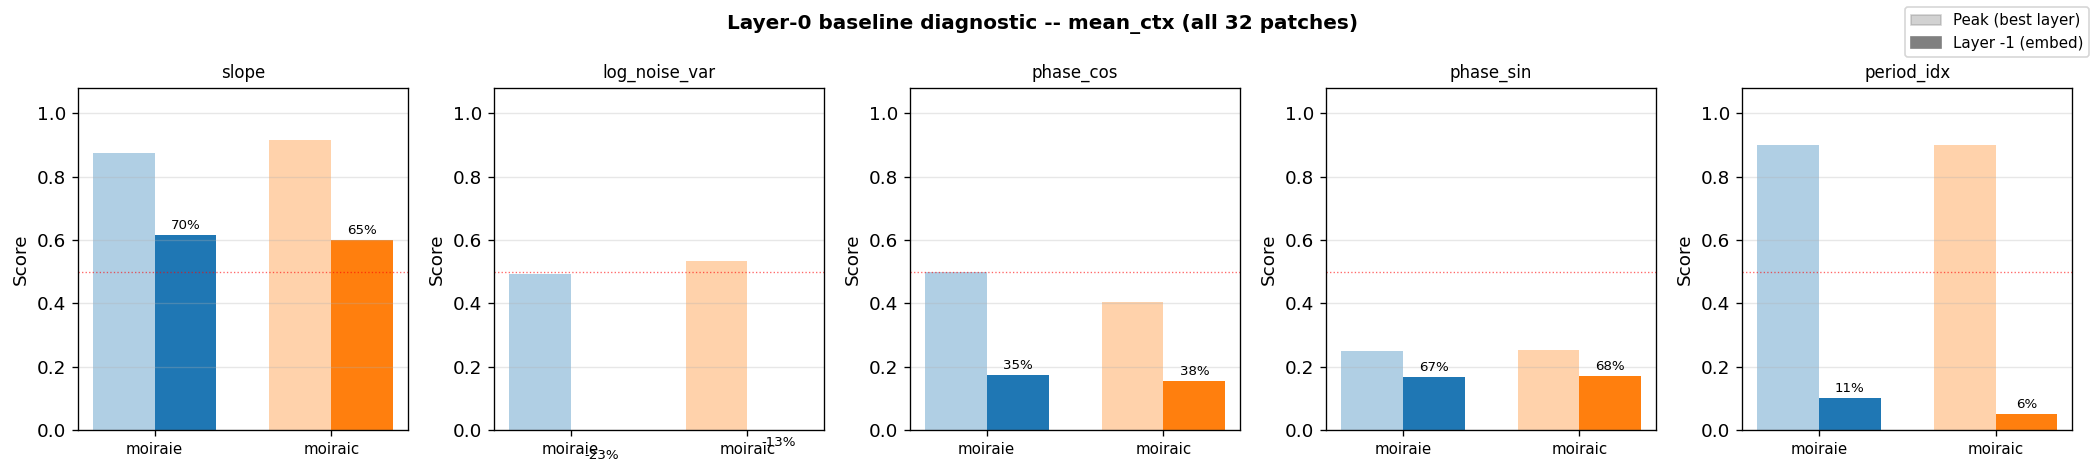

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr7/baseline_bar_last_ctx.pdf


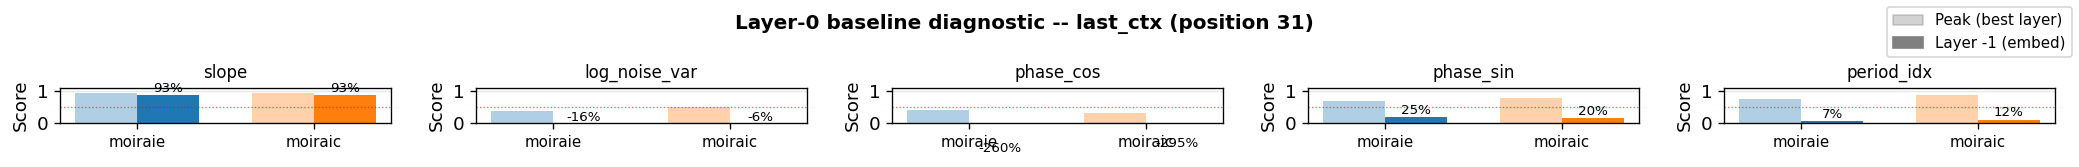

In [4]:
sorted_keys, x_pos, x_labels = layer_x_positions(all_layer_keys)

for pooling in POOLING_MODES:
    n_feat = len(all_features)
    fig, axes = plt.subplots(1, n_feat, figsize=(3.5 * n_feat, 4), sharey=False)
    if n_feat == 1:
        axes = [axes]

    for ax, feature in zip(axes, all_features):
        x = np.arange(len(model_names))
        w = 0.35
        embed_scores = []
        peak_scores  = []
        for mn in model_names:
            ls = results[mn][pooling].get(feature, {})
            embed_scores.append(ls.get(-1, float('nan')))
            peak_scores.append(max(ls.values()) if ls else float('nan'))

        ax.bar(x - w/2, peak_scores,  w, label='Peak (best layer)',
               color=[model_colors[n] for n in model_names], alpha=0.35)
        ax.bar(x + w/2, embed_scores, w, label='Layer -1 (embed)',
               color=[model_colors[n] for n in model_names], alpha=1.0)

        for xi, (e, p) in enumerate(zip(embed_scores, peak_scores)):
            if np.isfinite(e) and np.isfinite(p) and p > 0:
                ax.text(xi + w/2, e + 0.01, f'{e/p:.0%}',
                        ha='center', va='bottom', fontsize=8)

        ax.axhline(0.5, color='red', linestyle=':', linewidth=0.8, alpha=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, fontsize=9)
        ax.set_ylim(0, 1.08)
        ax.set_ylabel('Score')
        ax.set_title(feature, fontsize=10)
        ax.grid(True, axis='y', alpha=0.3)

    handles = [
        mpatches.Patch(color='gray', alpha=0.35, label='Peak (best layer)'),
        mpatches.Patch(color='gray', alpha=1.0,  label='Layer -1 (embed)'),
    ]
    fig.legend(handles=handles, loc='upper right', fontsize=9)
    fig.suptitle(f'Layer-0 baseline diagnostic -- {POOLING_LABELS[pooling]}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, f'baseline_bar_{pooling}.pdf')
    fig.savefig(path, bbox_inches='tight')
    print(f'Saved {path}')
    plt.show()
    plt.close(fig)


## 2 · Layer-emergence plots

Layer -1 (patch embedding) is in the **yellow shaded region**. The dotted vertical line separates it from the transformer layers.

**Solid** = `mean_ctx`, **dashed** = `last_ctx`.

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr7/emergence_slope.pdf


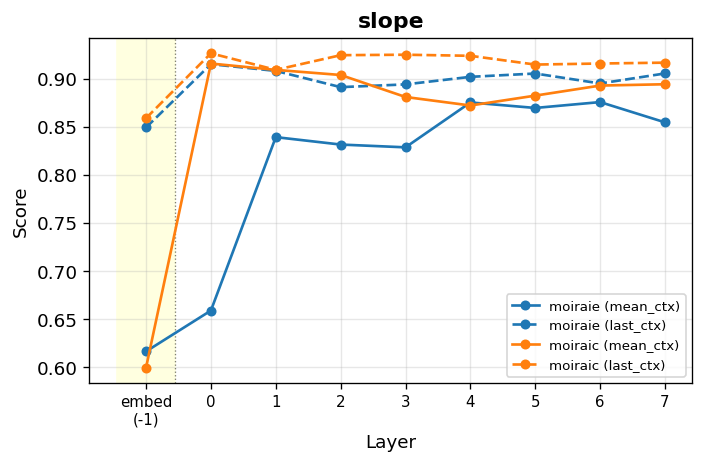

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr7/emergence_log_noise_var.pdf


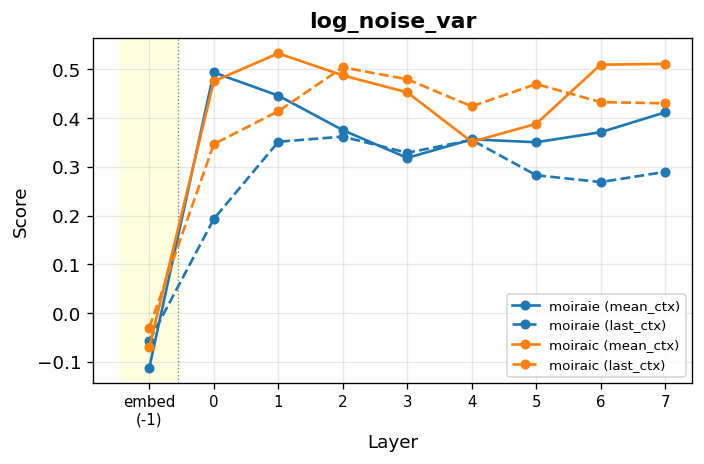

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr7/emergence_phase_cos.pdf


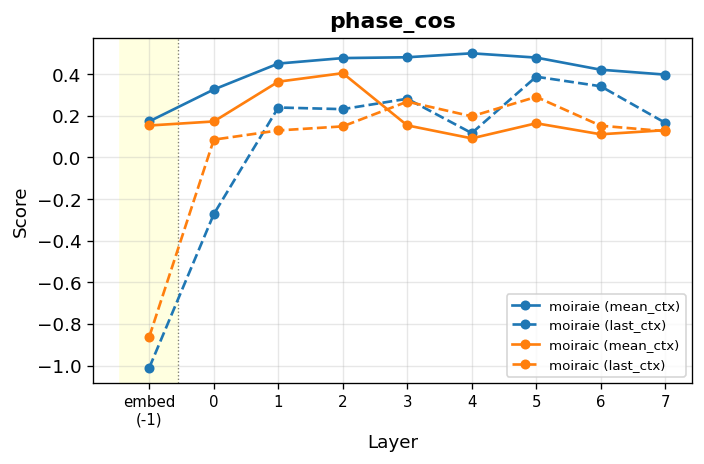

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr7/emergence_phase_sin.pdf


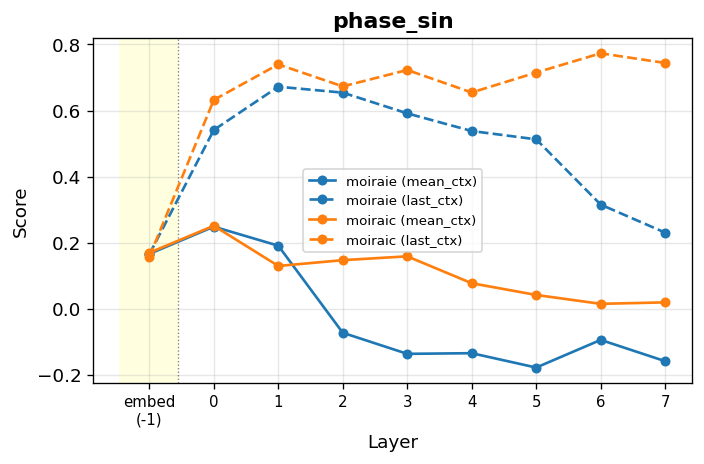

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr7/emergence_period_idx.pdf


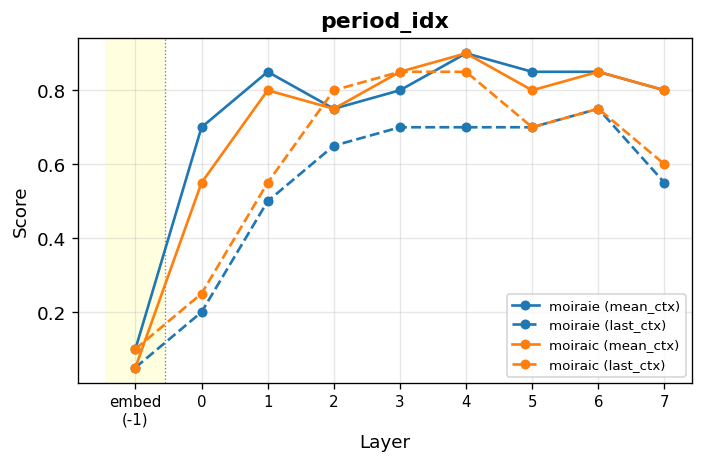

In [5]:
sorted_keys, x_pos, x_labels = layer_x_positions(all_layer_keys)
embed_xi = x_pos[sorted_keys.index(-1)]

for feature in all_features:
    fig, ax = plt.subplots(figsize=(6, 4))

    # Yellow band for embedding layer
    ax.axvspan(embed_xi - 0.45, embed_xi + 0.45, color='lightyellow', zorder=0)
    ax.axvline(embed_xi + 0.45, color='black', linestyle=':', linewidth=0.8, alpha=0.5)

    for model_name in model_names:
        color = model_colors[model_name]
        for pooling in POOLING_MODES:
            keys, scores = get_scores(results, model_name, pooling, feature)
            xs = [x_pos[sorted_keys.index(k)] for k in keys]
            ax.plot(xs, scores, marker='o', markersize=5,
                    linestyle=POOLING_LS[pooling], color=color, linewidth=1.6,
                    label=f'{model_name} ({pooling})')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Score')
    ax.set_title(feature, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, f'emergence_{feature}.pdf')
    fig.savefig(path, bbox_inches='tight')
    print(f'Saved {path}')
    plt.show()
    plt.close(fig)


## 3 · mean_ctx vs last_ctx pooling comparison

**Top panel**: both pooling modes overlaid per (model, feature).

**Bottom panel (delta)**: `last_ctx - mean_ctx`. Positive = last-position has higher score; negative = mean-pooling is better.

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr7/pooling_comparison_grid.pdf


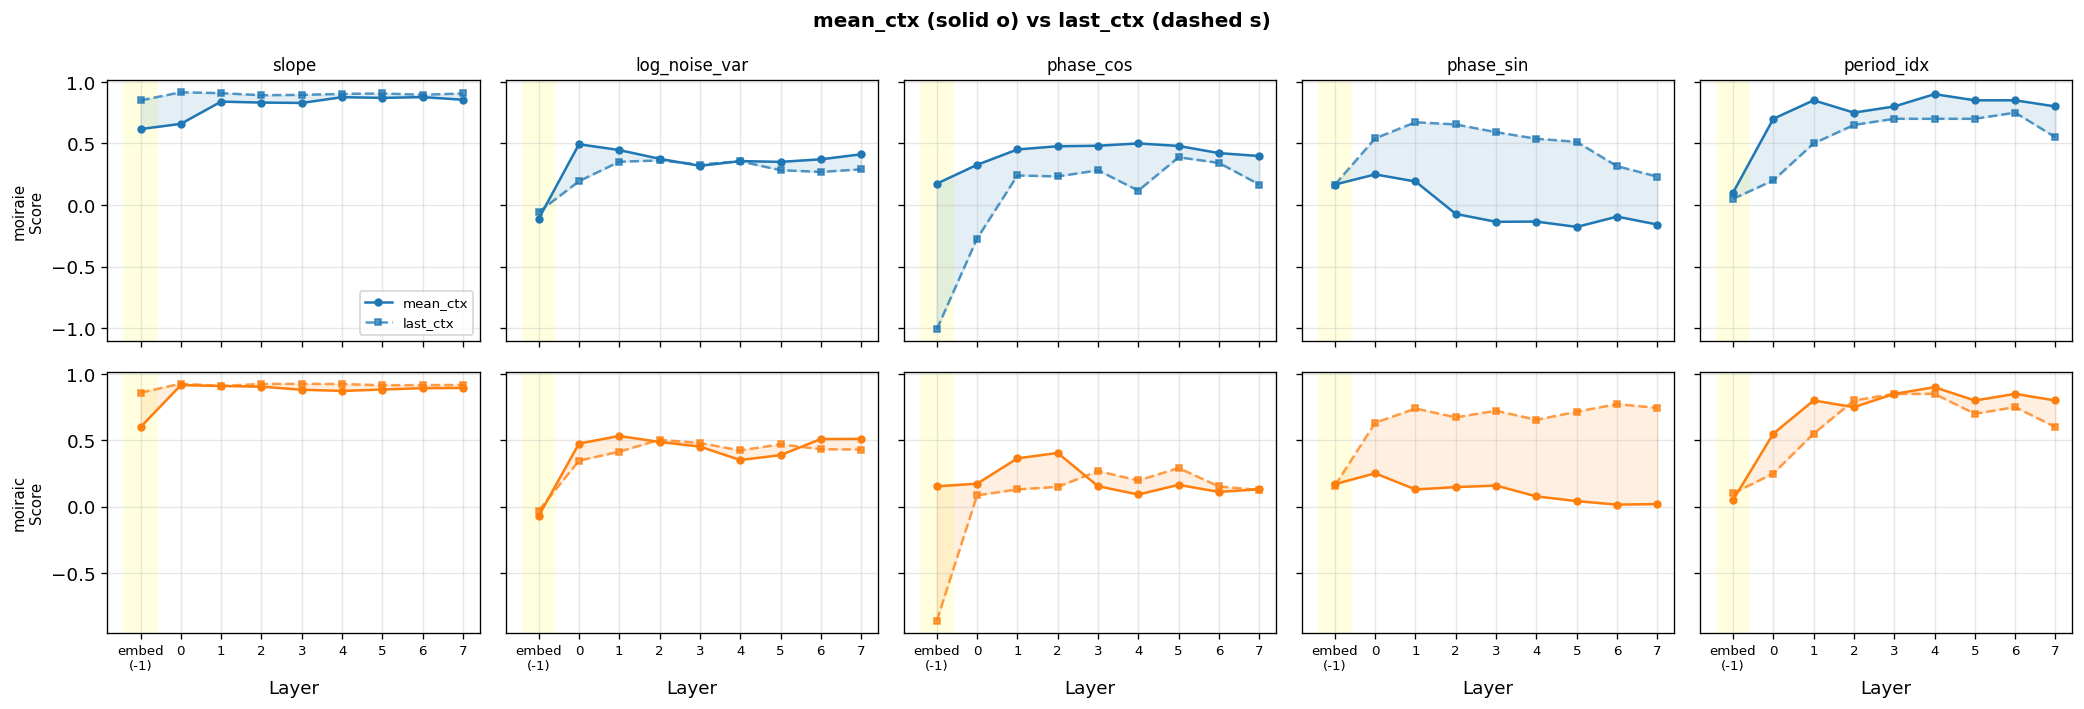

In [6]:
sorted_keys, x_pos, x_labels = layer_x_positions(all_layer_keys)
embed_xi = x_pos[sorted_keys.index(-1)]
n_feat = len(all_features)
n_mod  = len(model_names)

fig, axes = plt.subplots(n_mod, n_feat,
                         figsize=(3.5 * n_feat, 3.0 * n_mod),
                         sharey='row', sharex='col', squeeze=False)

for row, model_name in enumerate(model_names):
    for col, feature in enumerate(all_features):
        ax = axes[row][col]
        ax.axvspan(embed_xi - 0.4, embed_xi + 0.4, color='lightyellow', zorder=0)

        keys_m, scores_m = get_scores(results, model_name, 'mean_ctx', feature)
        keys_l, scores_l = get_scores(results, model_name, 'last_ctx', feature)
        xs_m = [x_pos[sorted_keys.index(k)] for k in keys_m]
        xs_l = [x_pos[sorted_keys.index(k)] for k in keys_l]

        color = model_colors[model_name]
        ax.plot(xs_m, scores_m, 'o-',  markersize=4, linewidth=1.5, color=color, label='mean_ctx')
        ax.plot(xs_l, scores_l, 's--', markersize=4, linewidth=1.5, color=color, alpha=0.75, label='last_ctx')

        # fill between the two curves
        common_keys = sorted(set(keys_m) & set(keys_l))
        xs_c = [x_pos[sorted_keys.index(k)] for k in common_keys]
        sm = np.array([scores_m[keys_m.index(k)] for k in common_keys])
        sl = np.array([scores_l[keys_l.index(k)] for k in common_keys])
        ax.fill_between(xs_c, sm, sl, alpha=0.12, color=color)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=8)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(feature, fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{model_name}\nScore', fontsize=9)
        if row == n_mod - 1:
            ax.set_xlabel('Layer')
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='lower right')

fig.suptitle('mean_ctx (solid o) vs last_ctx (dashed s)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
path = os.path.join(FIGURES_DIR, 'pooling_comparison_grid.pdf')
fig.savefig(path, bbox_inches='tight')
print(f'Saved {path}')
plt.show()
plt.close(fig)


Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr7/pooling_delta.pdf


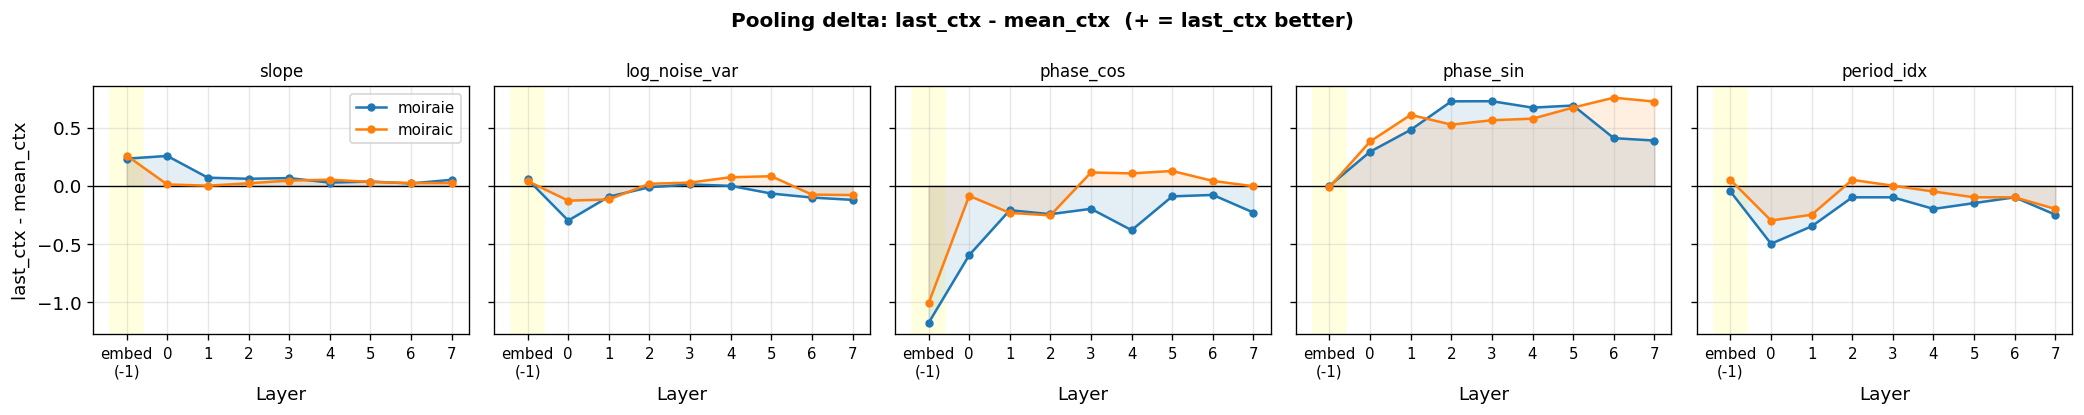

In [7]:
# Delta plot: last_ctx - mean_ctx
sorted_keys, x_pos, x_labels = layer_x_positions(all_layer_keys)
embed_xi = x_pos[sorted_keys.index(-1)]

fig, axes = plt.subplots(1, n_feat, figsize=(3.5 * n_feat, 3.5), sharey=True)
if n_feat == 1:
    axes = [axes]

for ax, feature in zip(axes, all_features):
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvspan(embed_xi - 0.4, embed_xi + 0.4, color='lightyellow', zorder=0)

    for model_name in model_names:
        keys_m, scores_m = get_scores(results, model_name, 'mean_ctx', feature)
        keys_l, scores_l = get_scores(results, model_name, 'last_ctx', feature)
        common_keys = sorted(set(keys_m) & set(keys_l))
        xs    = [x_pos[sorted_keys.index(k)] for k in common_keys]
        delta = np.array([scores_l[keys_l.index(k)] - scores_m[keys_m.index(k)]
                          for k in common_keys])
        color = model_colors[model_name]
        ax.plot(xs, delta, 'o-', markersize=4, linewidth=1.5, color=color, label=model_name)
        ax.fill_between(xs, 0, delta, alpha=0.12, color=color)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel('Layer')
    ax.grid(True, alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('last_ctx - mean_ctx')
        ax.legend(fontsize=9)

fig.suptitle('Pooling delta: last_ctx - mean_ctx  (+ = last_ctx better)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
path = os.path.join(FIGURES_DIR, 'pooling_delta.pdf')
fig.savefig(path, bbox_inches='tight')
print(f'Saved {path}')
plt.show()
plt.close(fig)


## 4 · Encoder vs decoder across both pooling modes

Row 1 = `mean_ctx`, row 2 = `last_ctx`. The **last_ctx row** is the fairest comparison: both models are queried at the same position (31) which has seen all 32 context patches.

Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr7/enc_dec_grid.pdf


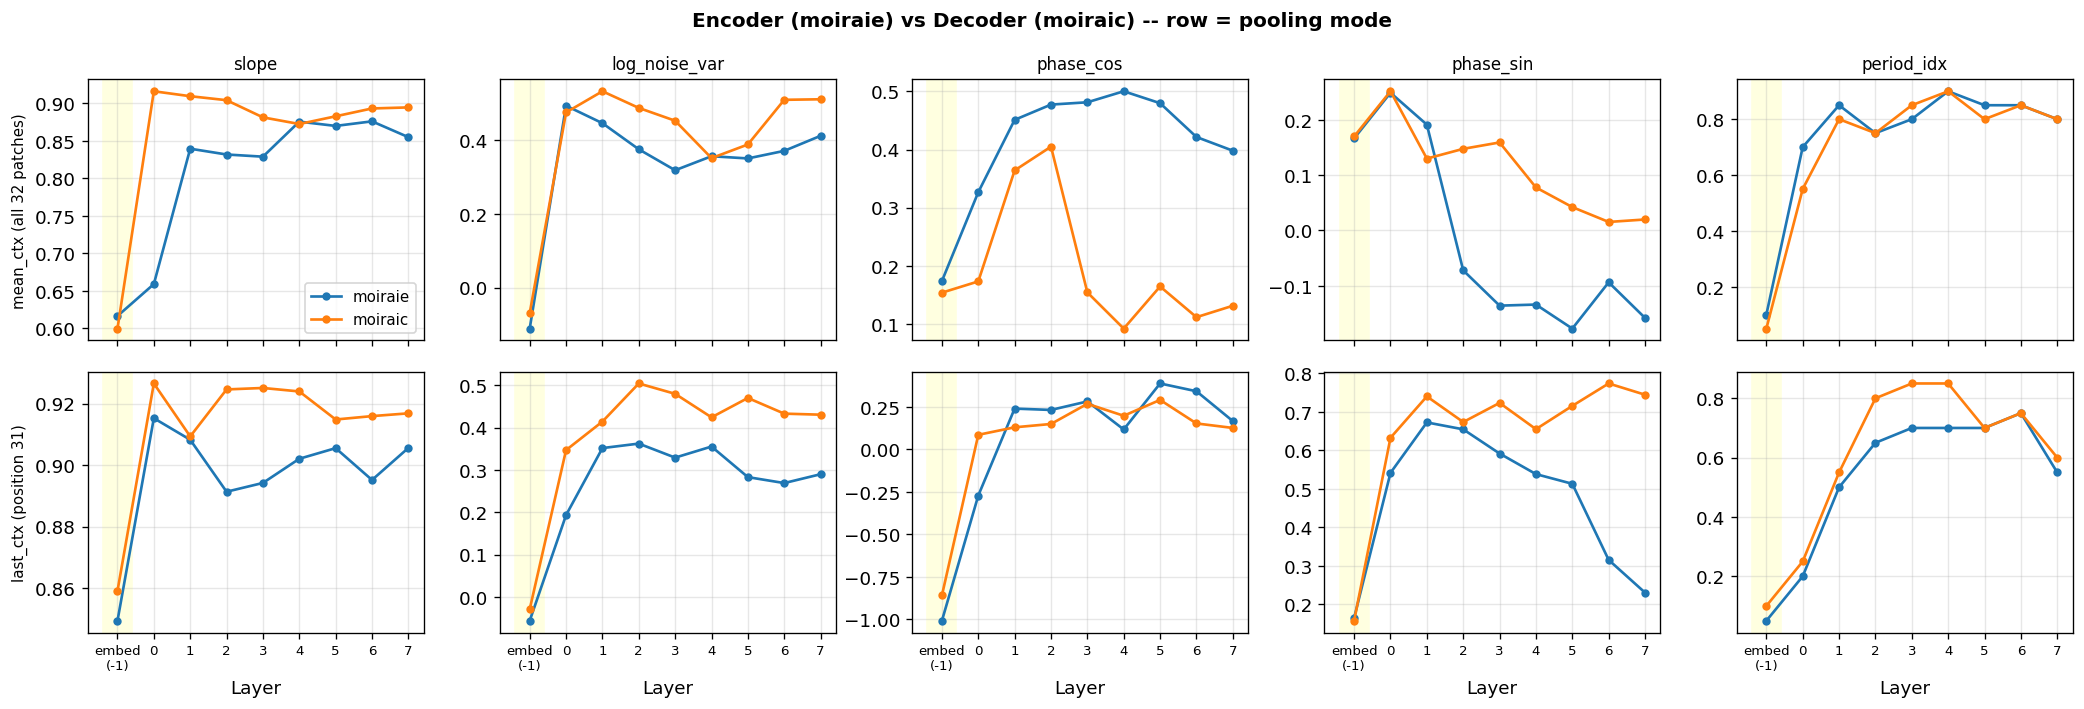

In [8]:
sorted_keys, x_pos, x_labels = layer_x_positions(all_layer_keys)
embed_xi = x_pos[sorted_keys.index(-1)]

fig, axes = plt.subplots(len(POOLING_MODES), n_feat,
                         figsize=(3.5 * n_feat, 3.0 * len(POOLING_MODES)),
                         sharex='col', squeeze=False)

for col, feature in enumerate(all_features):
    for row, pooling in enumerate(POOLING_MODES):
        ax = axes[row][col]
        ax.axvspan(embed_xi - 0.4, embed_xi + 0.4, color='lightyellow', zorder=0)

        for model_name in model_names:
            keys, scores = get_scores(results, model_name, pooling, feature)
            xs = [x_pos[sorted_keys.index(k)] for k in keys]
            ax.plot(xs, scores, 'o-', markersize=4, linewidth=1.6,
                    color=model_colors[model_name], label=model_name)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=8)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(feature, fontsize=10)
        if col == 0:
            ax.set_ylabel(POOLING_LABELS[pooling], fontsize=9)
        if row == len(POOLING_MODES) - 1:
            ax.set_xlabel('Layer')
        if row == 0 and col == 0:
            ax.legend(fontsize=9)

fig.suptitle('Encoder (moiraie) vs Decoder (moiraic) -- row = pooling mode',
             fontsize=12, fontweight='bold')
plt.tight_layout()
path = os.path.join(FIGURES_DIR, 'enc_dec_grid.pdf')
fig.savefig(path, bbox_inches='tight')
print(f'Saved {path}')
plt.show()
plt.close(fig)


## 5 · Summary table

In [9]:
rows = []
for model_name in model_names:
    for pooling in POOLING_MODES:
        for feature in all_features:
            ls = results[model_name][pooling].get(feature, {})
            if not ls:
                continue
            embed = ls.get(-1, float('nan'))
            peak  = max(ls.values())
            best  = max((k for k in ls if k >= 0), key=ls.get)
            rows.append({
                'Model':       model_name,
                'Pooling':     pooling,
                'Feature':     feature,
                'Embed (-1)':  round(embed, 4),
                'Peak':        round(peak, 4),
                'Best layer':  best,
                'Embed/Peak':  f'{embed/peak:.0%}' if peak > 0 else 'n/a',
            })

df = pd.DataFrame(rows)
path = os.path.join(FIGURES_DIR, 'pr7_summary.csv')
df.to_csv(path, index=False)
print(f'Saved {path}\n')
df


Saved /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/figures/pr7/pr7_summary.csv



,Model,Pooling,Feature,Embed (-1),Peak,Best layer,Embed/Peak
0,moiraie,mean_ctx,slope,0.6165,0.8758,6,70%
1,moiraie,mean_ctx,log_noise_var,-0.1114,0.4936,0,-23%
2,moiraie,mean_ctx,phase_cos,0.1736,0.5003,4,35%
3,moiraie,mean_ctx,phase_sin,0.1664,0.2488,0,67%
4,moiraie,mean_ctx,period_idx,0.1000,0.9000,4,11%
5,moiraie,last_ctx,slope,0.8494,0.9153,0,93%
6,moiraie,last_ctx,log_noise_var,-0.0564,0.3621,2,-16%
7,moiraie,last_ctx,phase_cos,-1.0087,0.3879,5,-260%
8,moiraie,last_ctx,phase_sin,0.1652,0.6722,1,25%
9,moiraie,last_ctx,period_idx,0.0500,0.7500,6,7%


## Interpretation guide

| Observation | Interpretation |
|---|---|
| **Embed/Peak > 60%** | Patch projection does most of the work; layers refine, not discover |
| **Embed/Peak < 20%** | Transformer blocks construct genuinely new representations |
| **last_ctx > mean_ctx** (decoder) | Causal model concentrates information at the last token |
| **mean_ctx > last_ctx** (encoder) | Bidirectional model distributes information across positions |
| **Encoder reaches peak earlier** (under last_ctx) | Bidirectional attention shortcut to feature formation |
| **Encoder ~= decoder** (under last_ctx) | Architecture gap appears at intermediate positions, not at position 31 |
